# 04 — Novelty Effect & Segment Analysis

Two advanced checks that separate senior analysts from juniors.

## Novelty Effect
Users sometimes click a redesigned page simply because it's new — not because it's better.
If the gap between treatment and control shrinks over time, the lift will evaporate post-launch.
We check by plotting daily conversion rates across the experiment duration.

## Segment Analysis
The overall average can hide what's happening to different user groups.
We test by day of week and time of day, then apply multiple testing correction.

**Corrections used:**
- **Bonferroni** — controls family-wise error rate (strict, use when false positives are costly)
- **Benjamini-Hochberg** — controls false discovery rate (less strict, better for many tests)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
%matplotlib inline

In [2]:
# Load cleaned dataset
df = pd.read_csv("ab_data_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create time-based features
df["experiment_day"] = (df["timestamp"] - df["timestamp"].min()).dt.days + 1
df["day_of_week"]    = df["timestamp"].dt.day_name()
df["hour"]           = df["timestamp"].dt.hour
df["time_of_day"]    = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]
)

# Print summary
print(f"{len(df):,} users  |  {df['experiment_day'].max()} experiment days")

# Preview dataset
print(df[["group", "converted", "experiment_day", "day_of_week", "time_of_day"]].head(4))

288,635 users  |  22 experiment days
       group  converted  experiment_day day_of_week        time_of_day
0  treatment          0               1      Monday  Afternoon (12-17)
1    control          0               1      Monday  Afternoon (12-17)
2    control          0               1      Monday  Afternoon (12-17)
3  treatment          0               1      Monday  Afternoon (12-17)


## Novelty Effect — Daily Conversion Rates

In [3]:
# Aggregate daily conversion rate and sample size
daily = (df.groupby(['experiment_day','group'])['converted']
           .agg(['mean','count'])
           .reset_index()
           .rename(columns={'mean':'rate','count':'n'}))

# Separate control and treatment daily rates
ctrl_d = daily[daily['group'] == 'control'].set_index('experiment_day')['rate']
trt_d  = daily[daily['group'] == 'treatment'].set_index('experiment_day')['rate']

# Apply 3-day centred rolling average
ctrl_roll = ctrl_d.rolling(3, min_periods=1, center=True).mean()
trt_roll  = trt_d.rolling(3, min_periods=1, center=True).mean()
gap       = (trt_roll - ctrl_roll) * 100

# Show first 5 days comparison
print("First 5 days:")
print(daily[daily['experiment_day'] <= 5]
      .pivot(index='experiment_day', columns='group', values='rate')
      .round(4))

First 5 days:
group           control  treatment
experiment_day                    
1                0.1200     0.1170
2                0.1155     0.1117
3                0.1231     0.1176
4                0.1181     0.1209
5                0.1214     0.1203


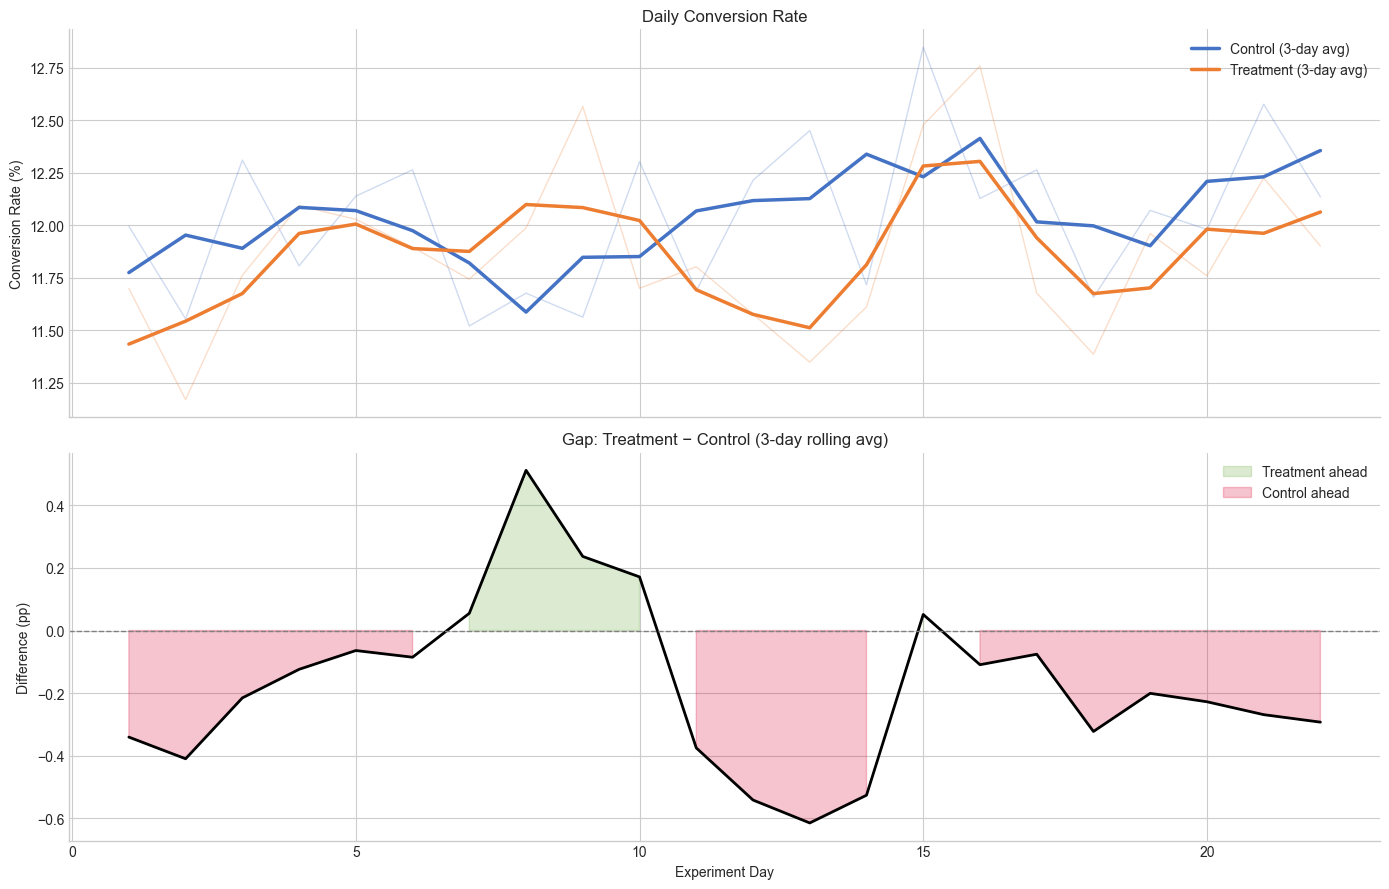

Avg gap first half:  -0.0580 pp
Avg gap second half: -0.2842 pp
Gap is stable — no obvious novelty effect


In [4]:
# Create two subplots for daily conversion and gap
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
days = ctrl_d.index

# Daily conversion rates
ax = axes[0]
ax.plot(days, ctrl_d*100, color='#4472C4', alpha=0.25, lw=1)
ax.plot(days, trt_d*100,  color='#ED7D31', alpha=0.25, lw=1)
ax.plot(days, ctrl_roll*100, color='#4472C4', lw=2.5, label="Control (3-day avg)")
ax.plot(days, trt_roll*100,  color='#ED7D31', lw=2.5, label="Treatment (3-day avg)")
ax.set_title("Daily Conversion Rate")
ax.set_ylabel("Conversion Rate (%)")
ax.legend()

# Gap between treatment and control
ax2 = axes[1]
ax2.fill_between(days, gap, 0, where=(gap >= 0), alpha=0.25, color='#70AD47', label="Treatment ahead")
ax2.fill_between(days, gap, 0, where=(gap < 0),  alpha=0.25, color='crimson', label="Control ahead")
ax2.plot(days, gap, color='black', lw=2)
ax2.axhline(0, color='gray', lw=1, linestyle='--')
ax2.set_title("Gap: Treatment − Control (3-day rolling avg)")
ax2.set_ylabel("Difference (pp)")
ax2.set_xlabel("Experiment Day")
ax2.legend()

# Show plot
plt.tight_layout()
plt.show()

# Compare average gap in first vs second half of experiment
mid = len(gap) // 2
print(f"Avg gap first half:  {gap.iloc[:mid].mean():+.4f} pp")
print(f"Avg gap second half: {gap.iloc[mid:].mean():+.4f} pp")

if abs(gap.iloc[mid:].mean()) < abs(gap.iloc[:mid].mean()):
    print("Gap is narrowing — possible novelty effect")
else:
    print("Gap is stable — no obvious novelty effect")

## Segment Analysis + Multiple Testing Correction

In [5]:
# Function to run chi-square tests for each segment
def segment_tests(df, col):
    out = []
    for level in sorted(df[col].dropna().unique()):
        seg  = df[df[col] == level]
        ctrl = seg[seg['group'] == 'control']
        trt  = seg[seg['group'] == 'treatment']

        # Skip small segments
        if len(ctrl) < 200 or len(trt) < 200:
            continue

        # Build contingency table
        table = [[ctrl['converted'].sum(), len(ctrl) - ctrl['converted'].sum()],
                 [trt['converted'].sum(),  len(trt)  - trt['converted'].sum()]]

        # Chi-square test
        _, p, _, _ = chi2_contingency(table)

        out.append({
            "segment":   str(level),
            "n_ctrl":    len(ctrl),
            "n_trt":     len(trt),
            "rate_ctrl": ctrl['converted'].mean(),
            "rate_trt":  trt['converted'].mean(),
            "lift_pp":   (trt['converted'].mean() - ctrl['converted'].mean()) * 100,
            "p_raw":     p
        })
    return pd.DataFrame(out)

# Run tests by day of week and time of day
dow = segment_tests(df, "day_of_week")
tod = segment_tests(df, "time_of_day")

# Combine results
all_seg = pd.concat([
    dow.assign(dim="Day of Week"),
    tod.assign(dim="Time of Day")
], ignore_index=True)

# Multiple testing corrections
p = all_seg["p_raw"].values
_, p_bonf, _, _ = multipletests(p, alpha=0.05, method="bonferroni")
_, p_bh,   _, _ = multipletests(p, alpha=0.05, method="fdr_bh")

all_seg["p_bonf"] = p_bonf
all_seg["p_bh"]   = p_bh

# Print results
print(all_seg[["dim","segment","rate_ctrl","rate_trt","lift_pp",
               "p_raw","p_bonf","p_bh"]].to_string(index=False, float_format="{:.4f}".format))

print()
print(f"Significant (uncorrected): {(all_seg['p_raw'] < 0.05).sum()} / {len(all_seg)}")
print(f"Significant (Bonferroni):  {(all_seg['p_bonf'] < 0.05).sum()} / {len(all_seg)}")
print(f"Significant (BH / FDR):    {(all_seg['p_bh'] < 0.05).sum()} / {len(all_seg)}")

        dim           segment  rate_ctrl  rate_trt  lift_pp  p_raw  p_bonf   p_bh
Day of Week            Friday     0.1155    0.1175   0.1988 0.5491  1.0000 0.5491
Day of Week            Monday     0.1231    0.1195  -0.3542 0.2553  1.0000 0.4012
Day of Week          Saturday     0.1243    0.1174  -0.6893 0.0373  0.4105 0.3438
Day of Week            Sunday     0.1196    0.1173  -0.2313 0.4861  1.0000 0.5347
Day of Week          Thursday     0.1220    0.1177  -0.4282 0.1985  1.0000 0.4012
Day of Week           Tuesday     0.1168    0.1219   0.5143 0.0885  0.9740 0.3438
Day of Week         Wednesday     0.1217    0.1187  -0.2973 0.3728  1.0000 0.5126
Time of Day Afternoon (12-17)     0.1214    0.1196  -0.1806 0.4629  1.0000 0.5347
Time of Day   Evening (18-23)     0.1195    0.1223   0.2792 0.2548  1.0000 0.4012
Time of Day    Morning (6-11)     0.1224    0.1187  -0.3749 0.1250  1.0000 0.3438
Time of Day       Night (0-5)     0.1182    0.1142  -0.4000 0.0961  1.0000 0.3438

Significant (un

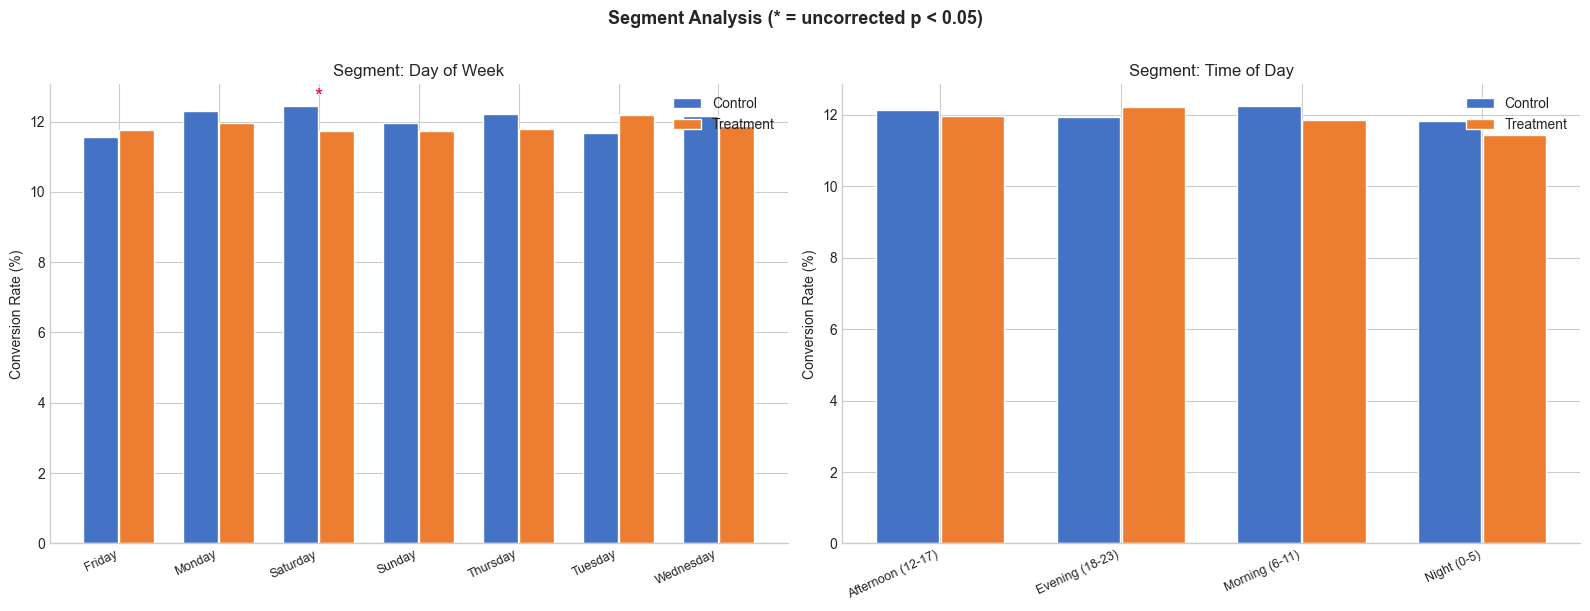

In [6]:
# Create two subplots for day-of-week and time-of-day segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#4472C4', '#ED7D31']

for ax, res, title in zip(axes, [dow, tod], ["Day of Week", "Time of Day"]):
    x = np.arange(len(res))

    # Bar plots for control vs treatment
    ax.bar(x - 0.18, res["rate_ctrl"]*100, 0.35, label="Control",   color=colors[0], edgecolor="white")
    ax.bar(x + 0.18, res["rate_trt"]*100, 0.35, label="Treatment", color=colors[1], edgecolor="white")

    # Mark significant segments (uncorrected p < 0.05)
    for i, (_, row) in enumerate(res.iterrows()):
        if row["p_raw"] < 0.05:
            ax.text(i, max(row["rate_ctrl"], row["rate_trt"])*100 + 0.1,
                    "*", ha="center", fontsize=15, color="crimson")

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(res["segment"].astype(str), rotation=25, ha="right", fontsize=9)
    ax.set_title(f"Segment: {title}")
    ax.set_ylabel("Conversion Rate (%)")
    ax.legend()

# Overall title
plt.suptitle("Segment Analysis (* = uncorrected p < 0.05)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()